<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/Temperature_analyse_compare_U1_U2_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

# =========================================================
# 1. FILE PATHS
# =========================================================
files = {
    "U1": {
        "electrical": r"u1_electrical_data_17_4_2026_R2.csv",
        "temp": r"u1_winding_temp_17_4_2026_R2.csv",
    },
    "U2": {
        "electrical": r"u2_electrical_data_6_4_2026_R2.csv",
        "temp": r"u2_winding_temp_6_4_2026_R2.csv",
    }
}

output_dir = Path("generator_year_comparison_outputs")
output_dir.mkdir(exist_ok=True)

In [3]:
# =========================================================
# 2. ROBUST FILE READER
# 2024 files seem comma-separated utf-8
# 2026 files seem tab-separated utf-16
# This function handles both
# =========================================================
def robust_read_csv(file_path):
    attempts = [
        {"encoding": "utf-16", "sep": "\t"},
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8", "sep": "\t"},
        {"encoding": "latin1", "sep": ","},
        {"encoding": "latin1", "sep": "\t"},
    ]

    last_error = None
    for cfg in attempts:
        try:
            df = pd.read_csv(file_path, encoding=cfg["encoding"], sep=cfg["sep"])
            if df.shape[1] > 1:
                df.columns = df.columns.str.strip()
                return df
        except Exception as e:
            last_error = e

    raise ValueError(f"Could not read file: {file_path}\nLast error: {last_error}")


UNIT SUMMARY
                                0            1
Unit                       Unit 1       Unit 2
Samples                       916          916
Mean MW                109.967957   108.405062
Mean MVAr              -18.459503   -19.217201
Mean PF                  0.965898     0.961978
Mean StatorCurrent     4583.34296  4550.167342
Mean FieldCurrent      822.817992   814.357434
Mean Current/MW         41.855727    42.034056
Mean FieldCurrent/MW     7.540995     7.556531
Mean Winding Temp       43.259181    39.822933
Mean Cooling Water       20.43897    10.916536
Mean Temp Rise          22.820211    28.906397
Mean Winding Diff        0.123955     0.531092
R2 Thermal Model         0.835791     0.786873
MAE Thermal Model        0.782222     0.901696
Mean Thermal Residual        -0.0          0.0
Std Thermal Residual     1.003233     1.207096
P95 |Residual|           1.903927     2.318289
Health Score            98.359578    85.443327

No common matched bins found for ['MW_bin', '

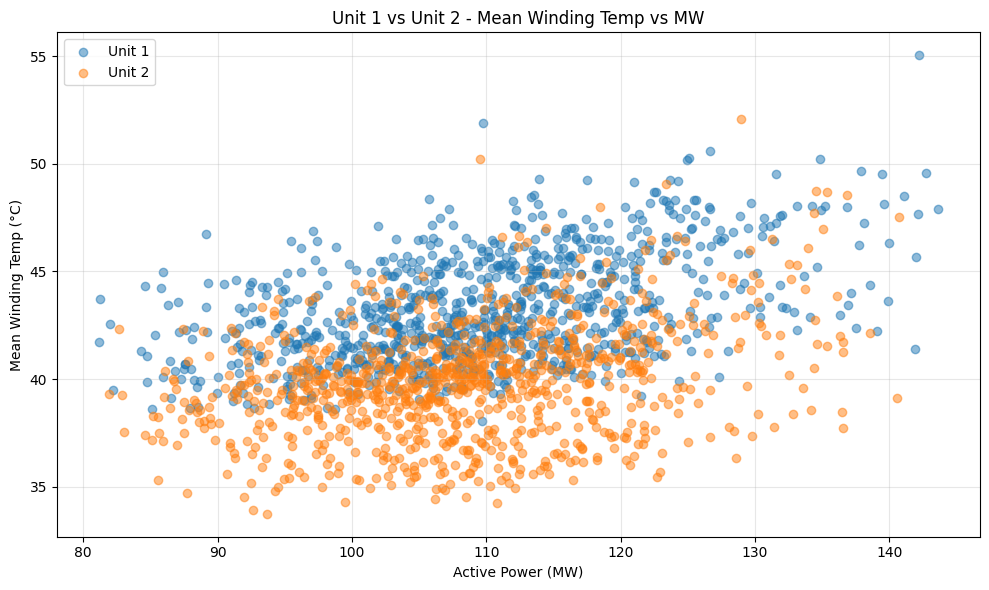

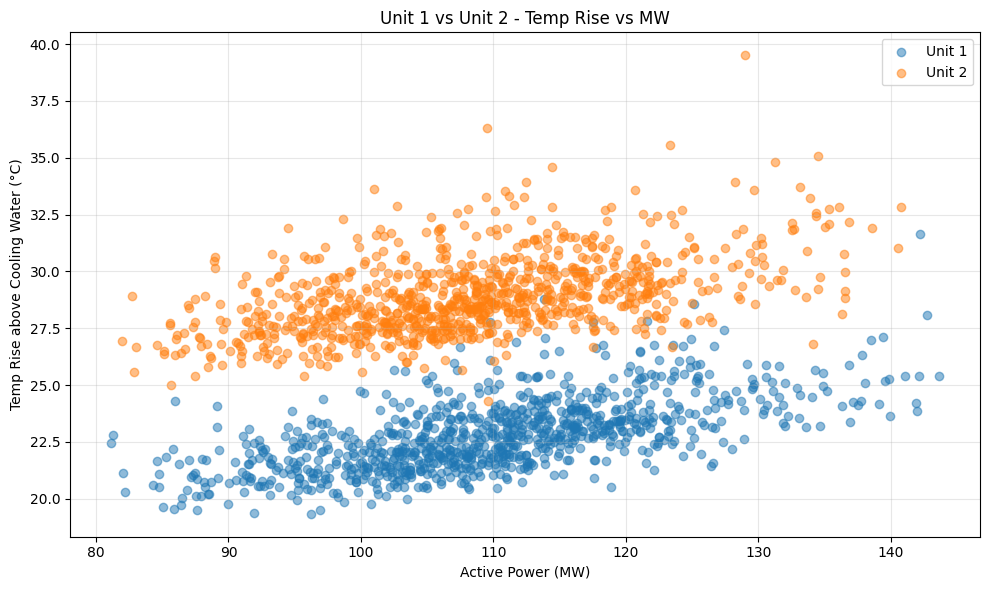

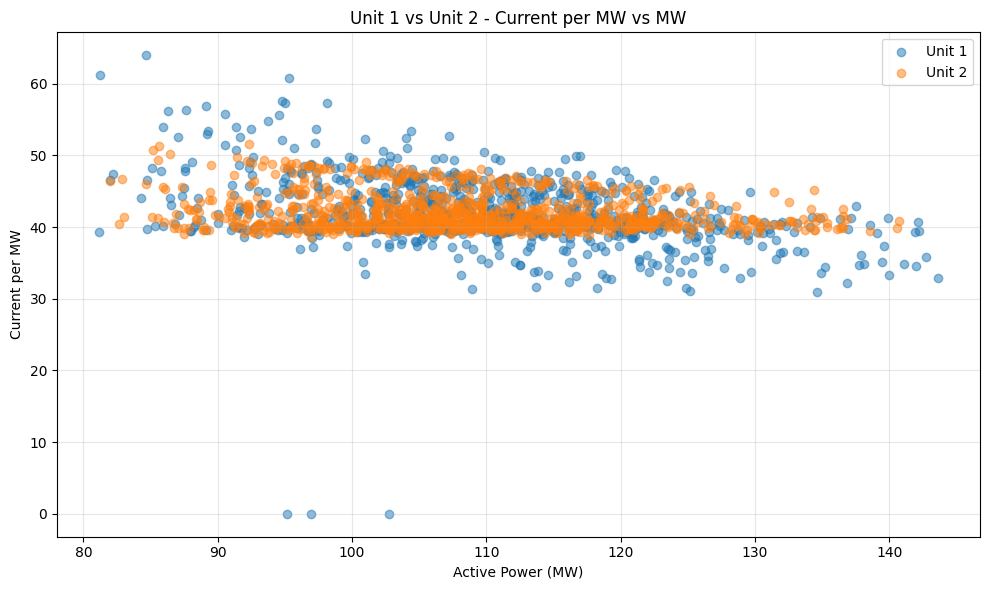

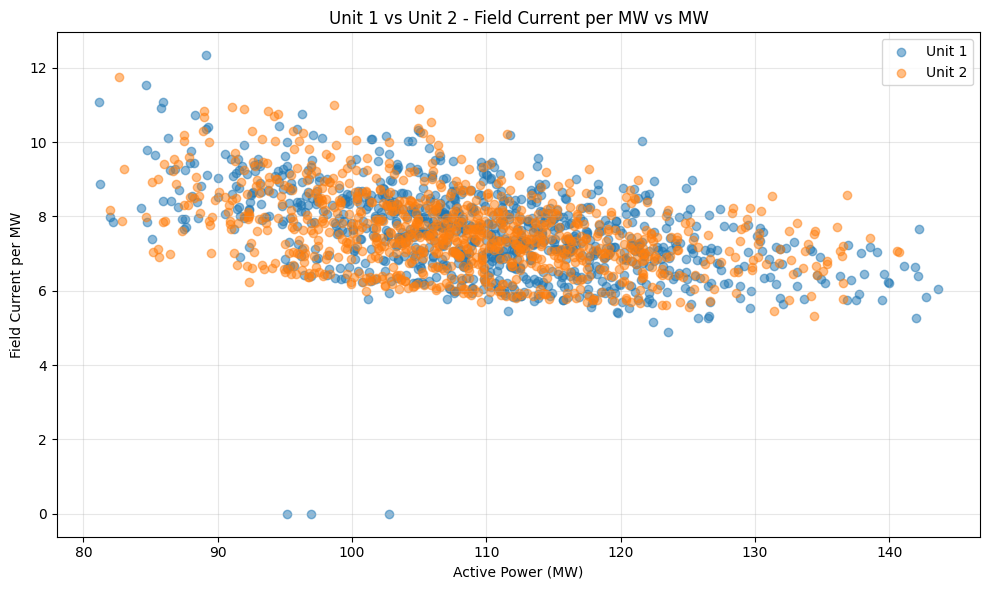

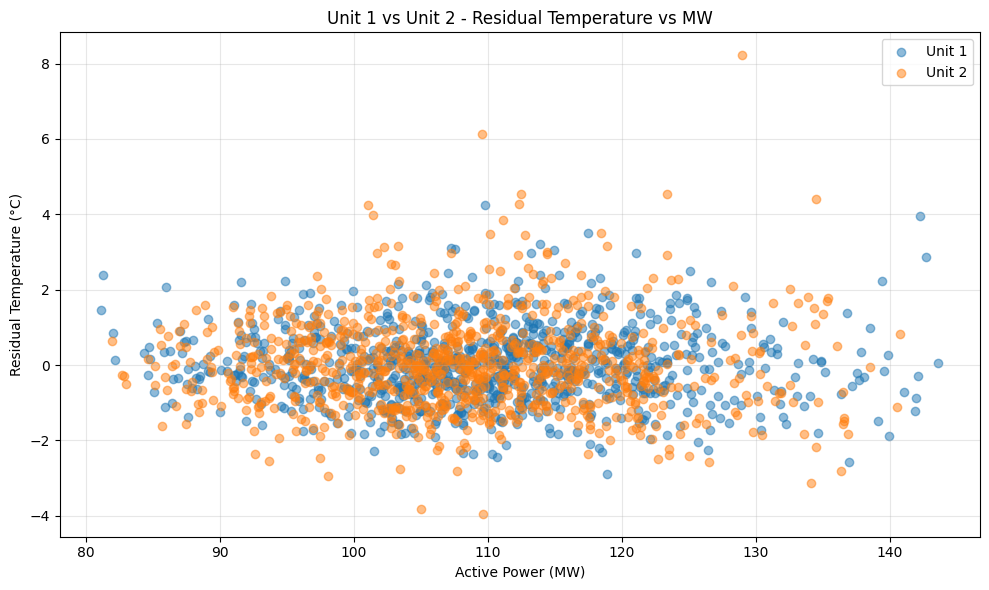

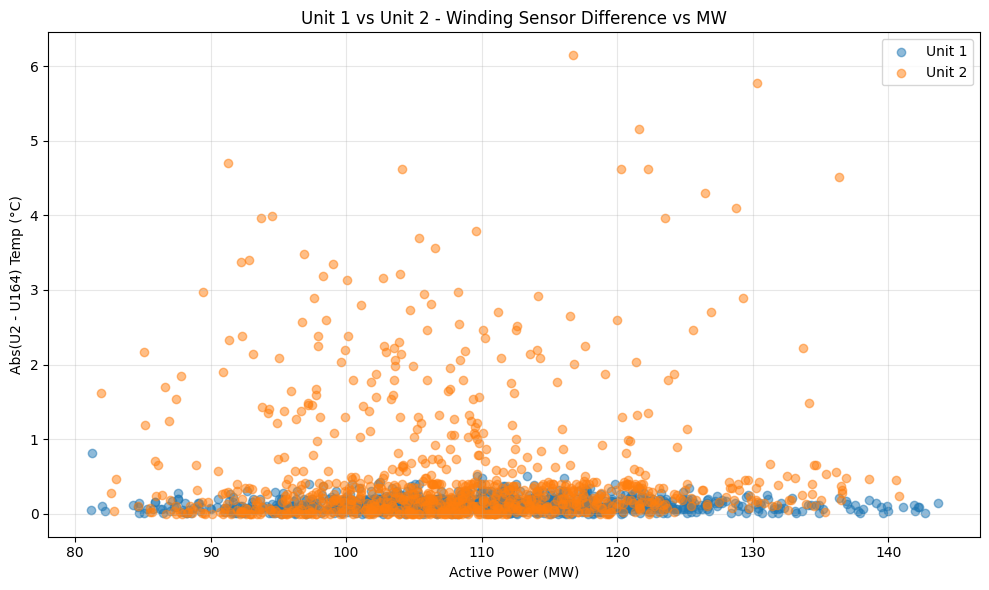

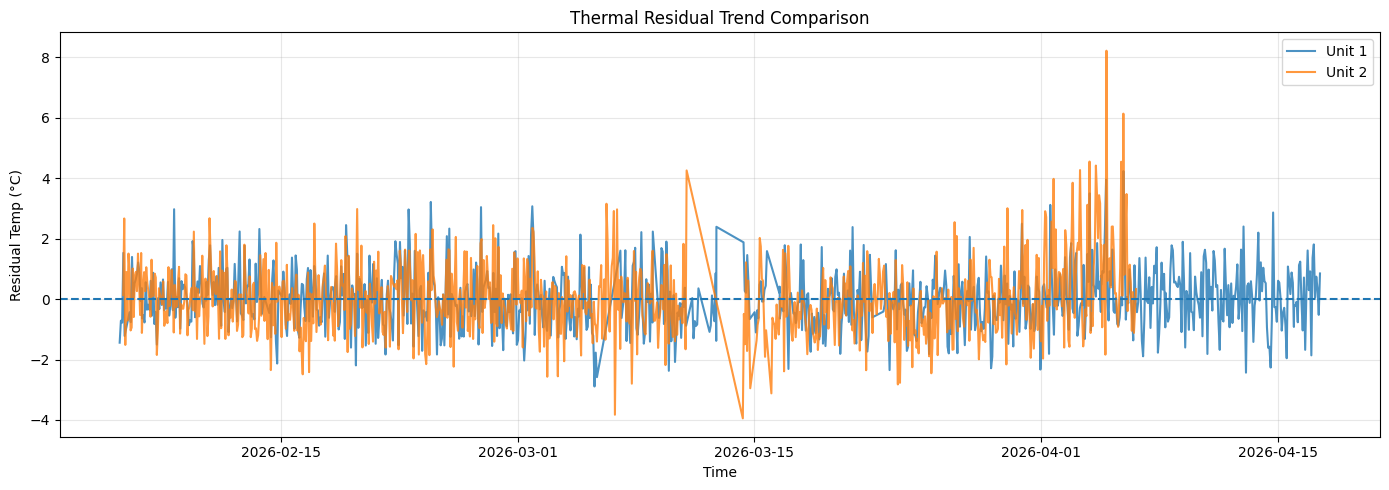

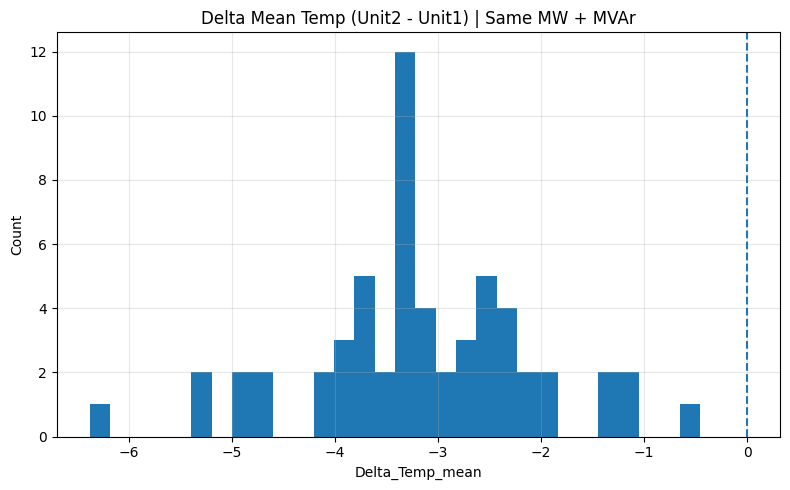

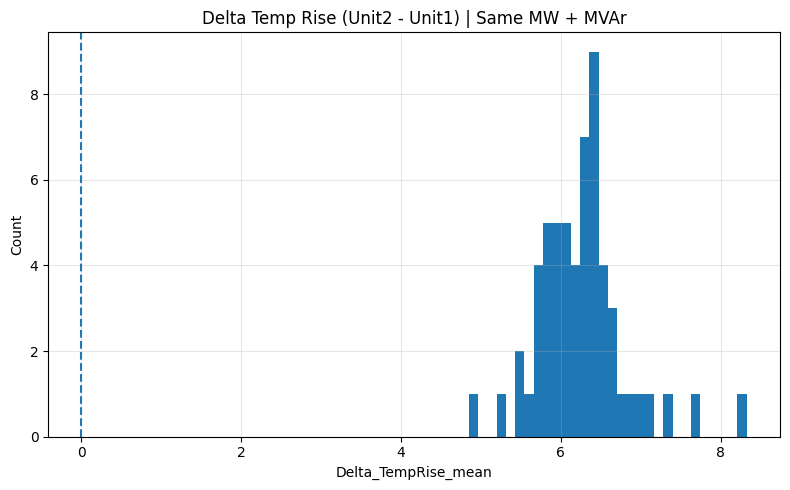

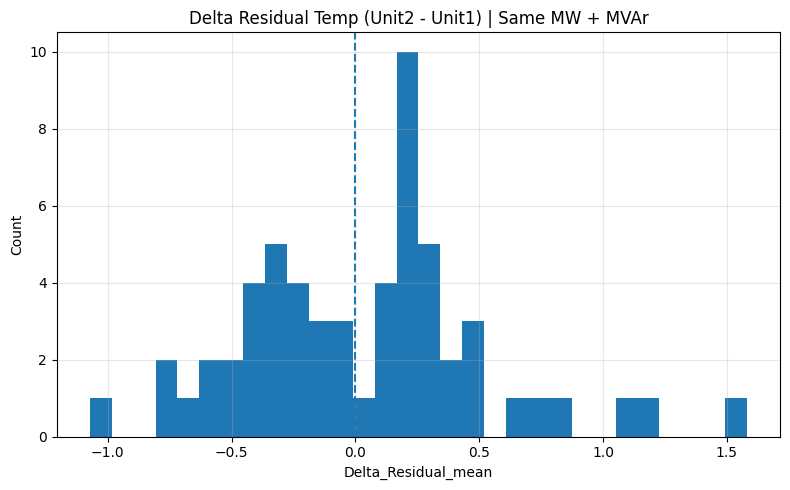

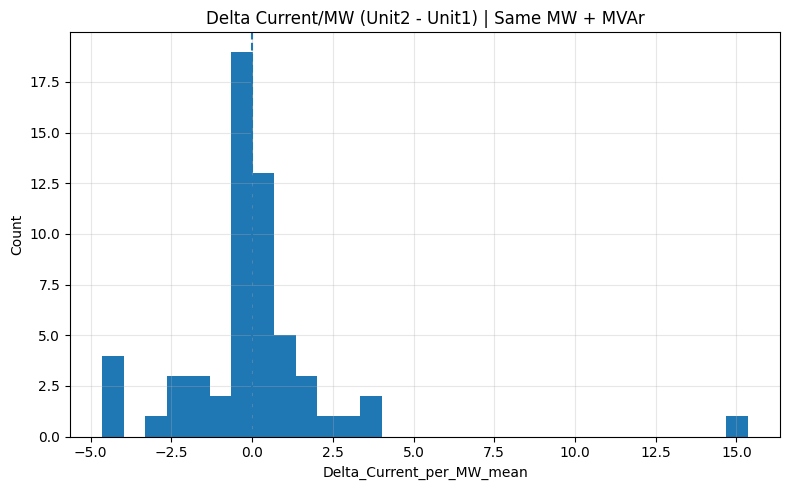

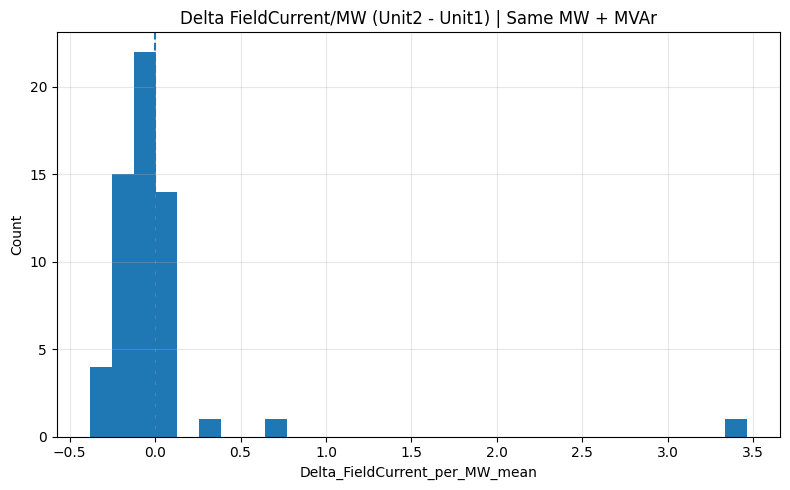

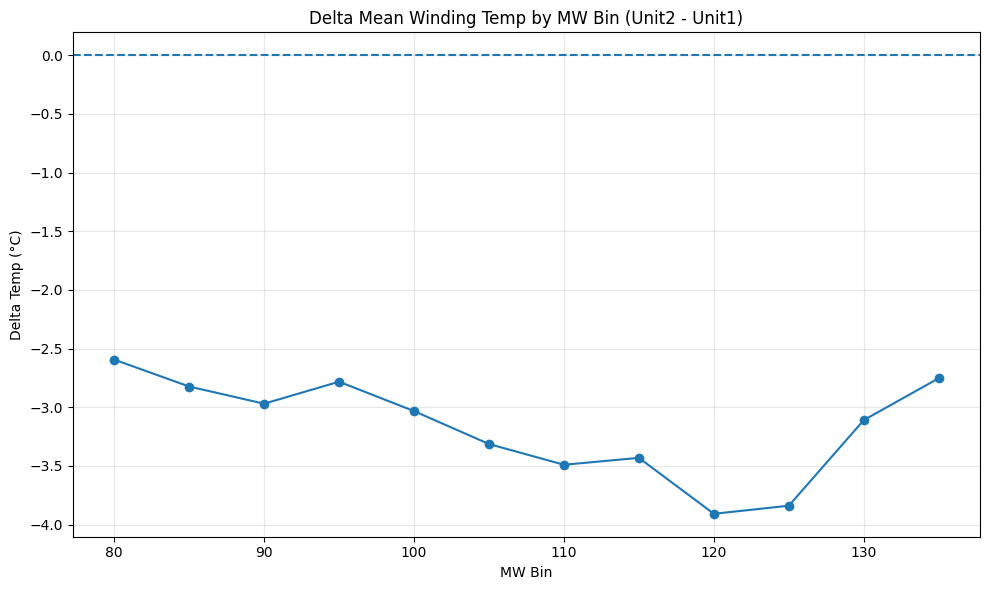

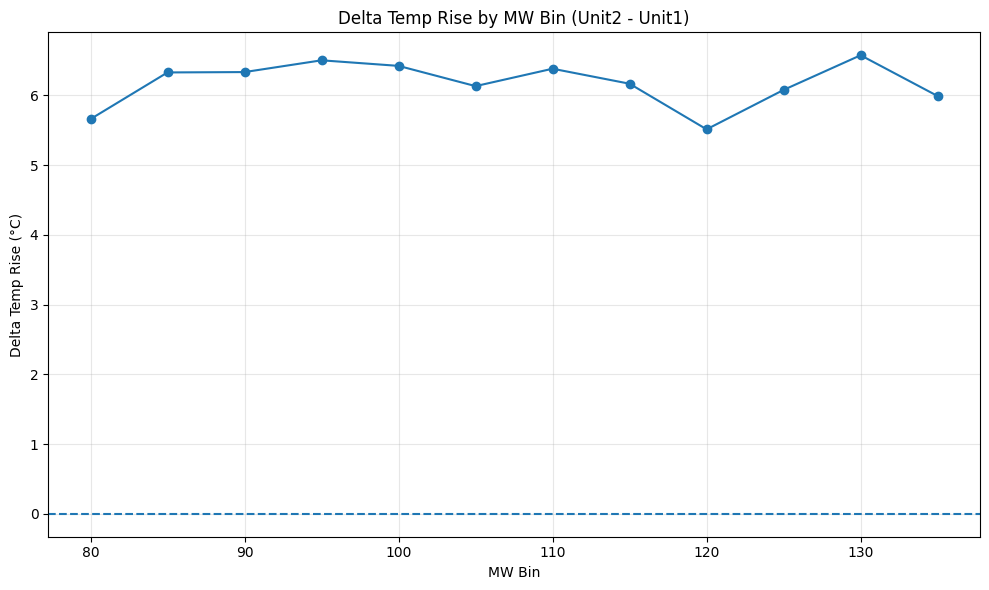

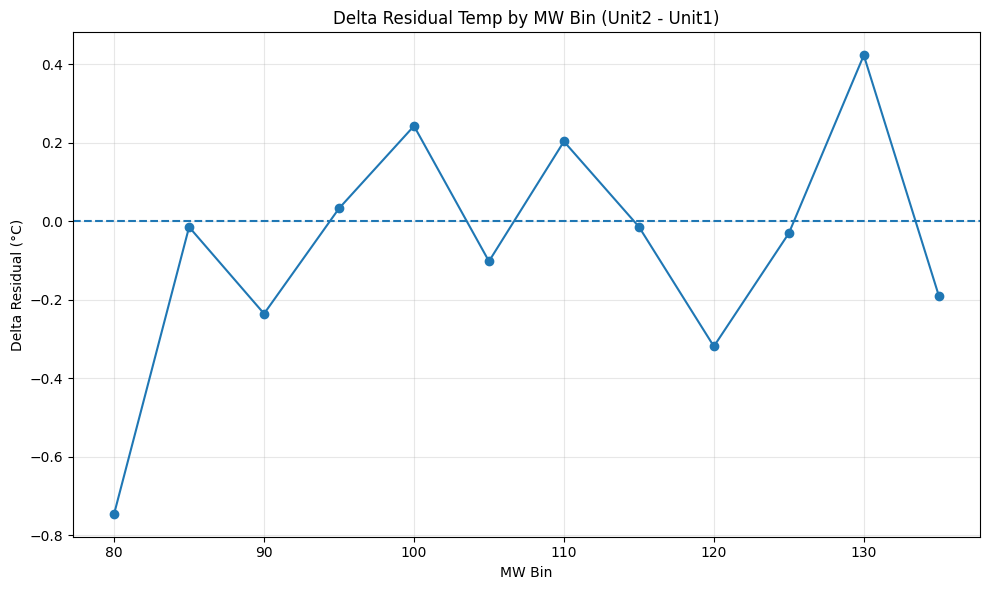

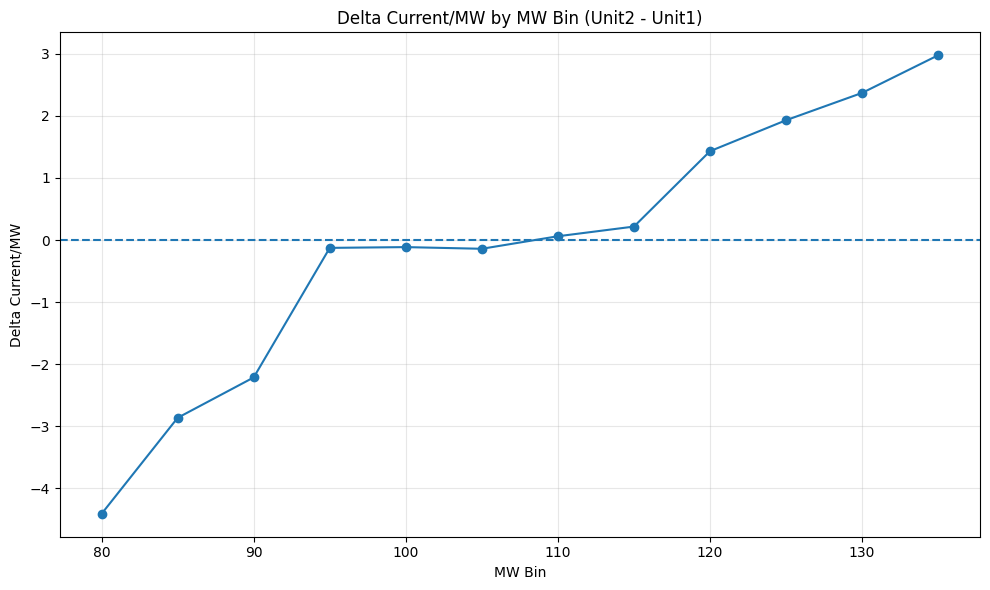

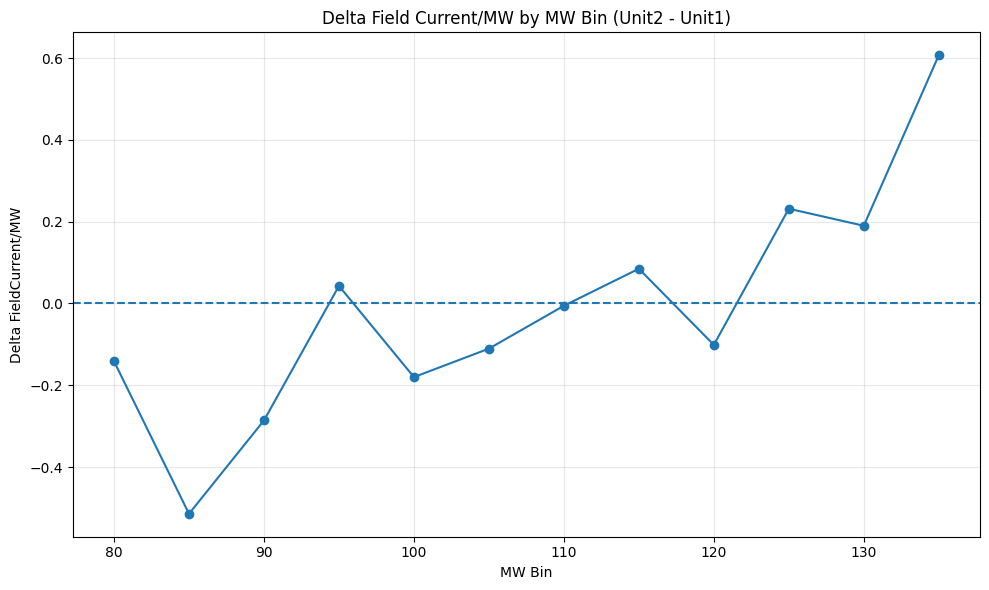


Files saved:
 - unit1_unit2_summary.xlsx
 - compare_unit1_unit2_same_MW.xlsx
 - compare_unit1_unit2_same_MW_MVAr.xlsx
 - compare_unit1_unit2_same_MW_MVAr_CW.xlsx


In [9]:

# Rename your real columns to these standard names
COLUMN_MAP = {
    # time
    "Timestamp": "timestamp",
    "timestamp": "timestamp",

    # electrical
    "Active_power(MW)": "MW",
    "Active Power": "MW",
    "MW": "MW",
    "Reactive_power(Mvar)": "MVAr",
    "Reactive Power": "MVAr",
    "MVAr": "MVAr",
    "Power Factor": "PF",
    "PF": "PF",
    "FIELD CURRENT": "FieldCurrent",
    "Field Current": "FieldCurrent",
    "FieldCurrent": "FieldCurrent",
    "UNIT CURRENT PHASE A": "StatorCurrent", # Assuming this represents the stator current
    "Stator Current": "StatorCurrent",
    "StatorCurrent": "StatorCurrent",

    # thermal
    "STATOR WINDING PHASE U2 TEMP": "Winding_U2",
    "Winding U2 Temp": "Winding_U2",
    "Winding_U2": "Winding_U2",
    "STATOR WINDING PHASE U164 TEMP": "Winding_U164",
    "Winding U164 Temp": "Winding_U164",
    "Winding_U164": "Winding_U164",
    "GENERATOR COOLING WATER INLET TEMP": "CW_Inlet",
    "Cooling Water Inlet Temp": "CW_Inlet",
    "CW_Inlet": "CW_Inlet",
}

# Bin settings
MW_BIN_WIDTH = 5
MVAR_BIN_WIDTH = 10
CW_BIN_WIDTH = 1.0

# Filtering limits
MW_MIN = 80
MW_MAX = 150
PF_MIN = 0.75
TEMP_MIN = 0
TEMP_MAX = 120
CW_MIN = 0
CW_MAX = 50

# If your files are CSV, set True
USE_CSV = False

# Define the TIME_COL global variable using COLUMN_MAP
TIME_COL = COLUMN_MAP["Timestamp"]

# Import necessary metrics for the thermal model
from sklearn.metrics import r2_score, mean_absolute_error


# =========================================================
# 2. LOAD DATA
# =========================================================

def load_file(file_path):
    file_path = Path(file_path)
    # Use the robust_read_csv function for all CSV files
    return robust_read_csv(file_path)


def standardize_columns(df, column_map):
    df = df.rename(columns=column_map)
    return df


def ensure_required_columns(df, required_cols, unit_name):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{unit_name}: Missing required columns: {missing}")


# =========================================================
# 3. PREPROCESSING
# =========================================================

def preprocess_unit(df, unit_name):
    df = df.copy()

    # Convert timestamp
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

    # Ensure necessary columns are numeric before calculations/filtering
    for col in ["MW", "MVAr", "FieldCurrent", "StatorCurrent", "Winding_U2", "Winding_U164", "CW_Inlet"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Calculate Power Factor if not present
    if "PF" not in df.columns:
        # Only calculate for rows where MW and MVAr are available
        df_temp = df.dropna(subset=["MW", "MVAr"]).copy()
        if not df_temp.empty:
            df.loc[df_temp.index, "PF"] = df_temp["MW"] / np.sqrt(df_temp["MW"]**2 + df_temp["MVAr"]**2)
        # If MW or MVAr are NaN, PF will remain NaN and be dropped later

    # Now convert PF to numeric, handling cases where it was already there or calculated
    df["PF"] = pd.to_numeric(df["PF"], errors="coerce")

    # Basic filtering
    df = df.dropna(subset=["MW", "MVAr", "PF", "FieldCurrent",
                           "StatorCurrent", "Winding_U2", "Winding_U164", "CW_Inlet"])

    df = df[
        (df["MW"] >= MW_MIN) & (df["MW"] <= MW_MAX) &
        (df["PF"].abs() >= PF_MIN) &
        (df["Winding_U2"].between(TEMP_MIN, TEMP_MAX)) &
        (df["Winding_U164"].between(TEMP_MIN, TEMP_MAX)) &
        (df["CW_Inlet"].between(CW_MIN, CW_MAX))
    ].copy()

    # Derived features
    df["MeanWindingTemp"] = df[["Winding_U2", "Winding_U164"]].mean(axis=1)
    df["WindingDiff"] = (df["Winding_U2"] - df["Winding_U164"]).abs()
    df["TempRise"] = df["MeanWindingTemp"] - df["CW_Inlet"]
    df["Current_per_MW"] = df["StatorCurrent"] / df["MW"]
    df["FieldCurrent_per_MW"] = df["FieldCurrent"] / df["MW"]
    df["Unit"] = unit_name

    # Bins
    df["MW_bin"] = (np.floor(df["MW"] / MW_BIN_WIDTH) * MW_BIN_WIDTH).astype(float)
    df["MVAr_bin"] = (np.floor(df["MVAr"] / MVAR_BIN_WIDTH) * MVAR_BIN_WIDTH).astype(float)
    df["CW_bin"] = (np.floor(df["CW_Inlet"] / CW_BIN_WIDTH) * CW_BIN_WIDTH).astype(float)

    return df.sort_values(TIME_COL).reset_index(drop=True)


# =========================================================
# 4. THERMAL MODEL
# =========================================================

def build_thermal_model(df):
    """
    Predict mean winding temperature from operating conditions.
    """
    features = ["MW", "MVAr", "PF", "FieldCurrent", "StatorCurrent", "CW_Inlet"]
    X = df[features].copy()
    y = df["MeanWindingTemp"].copy()

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)
    residual = y - pred

    result = df.copy()
    result["PredTemp"] = pred
    result["ResidualTemp"] = residual

    metrics = {
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "ResidualMean": residual.mean(),
        "ResidualStd": residual.std(),
        "ResidualP95Abs": np.percentile(np.abs(residual), 95),
    }

    return model, result, metrics


# =========================================================
# 5. KPI SUMMARY
# =========================================================

def unit_summary(df, metrics, unit_name):
    summary = {
        "Unit": unit_name,
        "Samples": len(df),
        "Mean MW": df["MW"].mean(),
        "Mean MVAr": df["MVAr"].mean(),
        "Mean PF": df["PF"].abs().mean(),
        "Mean StatorCurrent": df["StatorCurrent"].mean(),
        "Mean FieldCurrent": df["FieldCurrent"].mean(),
        "Mean Current/MW": df["Current_per_MW"].mean(),
        "Mean FieldCurrent/MW": df["FieldCurrent_per_MW"].mean(),
        "Mean Winding Temp": df["MeanWindingTemp"].mean(),
        "Mean Cooling Water": df["CW_Inlet"].mean(),
        "Mean Temp Rise": df["TempRise"].mean(),
        "Mean Winding Diff": df["WindingDiff"].mean(),
        "R2 Thermal Model": metrics["R2"],
        "MAE Thermal Model": metrics["MAE"],
        "Mean Thermal Residual": metrics["ResidualMean"],
        "Std Thermal Residual": metrics["ResidualStd"],
        "P95 |Residual|": metrics["ResidualP95Abs"],
    }
    return summary


# =========================================================
# 6. MATCHED BIN COMPARISON
# =========================================================

def grouped_stats(df, group_cols, min_count=5):
    agg = (
        df.groupby(group_cols)
        .agg(
            Count=("MeanWindingTemp", "size"),
            MW_mean=("MW", "mean"),
            MVAr_mean=("MVAr", "mean"),
            CW_mean=("CW_Inlet", "mean"),
            PF_mean=("PF", "mean"),
            Temp_mean=("MeanWindingTemp", "mean"),
            TempRise_mean=("TempRise", "mean"),
            Residual_mean=("ResidualTemp", "mean"),
            Residual_std=("ResidualTemp", "std"),
            Current_per_MW_mean=("Current_per_MW", "mean"),
            FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
            WindingDiff_mean=("WindingDiff", "mean"),
        )
        .reset_index()
    )

    return agg[agg["Count"] >= min_count].copy()


def compare_two_units_by_bins(df1, df2, group_cols, suffix1="U1", suffix2="U2", min_count=5):
    g1 = grouped_stats(df1, group_cols, min_count=min_count)
    g2 = grouped_stats(df2, group_cols, min_count=min_count)

    merged = pd.merge(g1, g2, on=group_cols, suffixes=(f"_{suffix1}", f"_{suffix2}"))

    if len(merged) == 0:
        print(f"\nNo common matched bins found for {group_cols}")
        return merged

    # Delta = Unit2 - Unit1
    for metric in [
        "Temp_mean", "TempRise_mean", "Residual_mean",
        "Current_per_MW_mean", "FieldCurrent_per_MW_mean",
        "WindingDiff_mean"
    ]:
        merged[f"Delta_{metric}"] = merged[f"{metric}_{suffix2}"] - merged[f"{metric}_{suffix1}"]

    return merged


def print_bin_comparison_summary(merged, label):
    if len(merged) == 0:
        return

    print(f"\n{'='*70}")
    print(f"MATCHED BIN COMPARISON: {label}")
    print(f"Common bins: {len(merged)}")
    print(f"{'='*70}")

    metrics = [
        "Delta_Temp_mean",
        "Delta_TempRise_mean",
        "Delta_Residual_mean",
        "Delta_Current_per_MW_mean",
        "Delta_FieldCurrent_per_MW_mean",
        "Delta_WindingDiff_mean",
    ]

    for m in metrics:
        print(
            f"{m:35s} | "
            f"mean = {merged[m].mean():8.3f} | "
            f"median = {merged[m].median():8.3f} | "
            f"std = {merged[m].std():8.3f}"
        )


# =========================================================
# 7. PLOTS
# =========================================================

def plot_side_by_side_scatter(df1, df2, x, y, title, xlabel=None, ylabel=None):
    plt.figure(figsize=(10, 6))
    plt.scatter(df1[x], df1[y], alpha=0.5, label="Unit 1")
    plt.scatter(df2[x], df2[y], alpha=0.5, label="Unit 2")
    plt.title(title)
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_delta_hist(merged, col, title):
    if len(merged) == 0:
        return

    plt.figure(figsize=(8, 5))
    plt.hist(merged[col], bins=30)
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_time_residual(df1, df2):
    plt.figure(figsize=(14, 5))
    plt.plot(df1[TIME_COL], df1["ResidualTemp"], label="Unit 1", alpha=0.8)
    plt.plot(df2[TIME_COL], df2["ResidualTemp"], label="Unit 2", alpha=0.8)
    plt.axhline(0, linestyle="--")
    plt.title("Thermal Residual Trend Comparison")
    plt.xlabel("Time")
    plt.ylabel("Residual Temp (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_binned_line(merged, x_col, y_col, title, xlabel=None, ylabel=None):
    if len(merged) == 0:
        return

    merged = merged.sort_values(x_col)
    plt.figure(figsize=(10, 6))
    plt.plot(merged[x_col], merged[y_col], marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(title)
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel or y_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. HEALTH SCORE (OPTIONAL)
# =========================================================

def compute_health_score(df, summary_dict):
    """
    Higher score = better.
    You can change weights later.
    """
    # Normalize around internal dataset references
    score = 100.0

    # Thermal
    score -= 2.0 * max(0, summary_dict["Mean Temp Rise"] - 22)
    score -= 10.0 * max(0, summary_dict["Std Thermal Residual"] - 1.2)
    score -= 20.0 * max(0, summary_dict["Mean Winding Diff"] - 0.5)

    # Electrical
    score -= 1.5 * max(0, summary_dict["Mean Current/MW"] - 42)
    score -= 4.0 * max(0, summary_dict["Mean FieldCurrent/MW"] - 8.0)

    score = max(0, min(100, score))
    return score


# =========================================================
# 9. MAIN
# =========================================================

def main():
    required_cols = [
        "timestamp", "MW", "MVAr", "PF", "FieldCurrent", "StatorCurrent",
        "Winding_U2", "Winding_U164", "CW_Inlet"
    ]

    # Load data for Unit 1
    elec_df1 = load_file(files["U1"]["electrical"])
    temp_df1 = load_file(files["U1"]["temp"])

    # Standardize columns before merging to ensure consistent column names for merging
    elec_df1 = standardize_columns(elec_df1, COLUMN_MAP)
    temp_df1 = standardize_columns(temp_df1, COLUMN_MAP)

    # Merge electrical and temperature data for Unit 1
    raw1 = pd.merge(elec_df1, temp_df1, on=TIME_COL, how="outer")

    # Load data for Unit 2
    elec_df2 = load_file(files["U2"]["electrical"])
    temp_df2 = load_file(files["U2"]["temp"])

    # Standardize columns before merging
    elec_df2 = standardize_columns(elec_df2, COLUMN_MAP)
    temp_df2 = standardize_columns(temp_df2, COLUMN_MAP)
    # Merge electrical and temperature data for Unit 2
    raw2 = pd.merge(elec_df2, temp_df2, on=TIME_COL, how="outer")

    # Preprocess
    u1 = preprocess_unit(raw1, "Unit 1")
    u2 = preprocess_unit(raw2, "Unit 2")

    ensure_required_columns(u1, required_cols, "Unit 1")
    ensure_required_columns(u2, required_cols, "Unit 2")

    # Thermal model per unit
    model1, u1, metrics1 = build_thermal_model(u1)
    model2, u2, metrics2 = build_thermal_model(u2)

    # Summary
    summary1 = unit_summary(u1, metrics1, "Unit 1")
    summary2 = unit_summary(u2, metrics2, "Unit 2")

    summary_df = pd.DataFrame([summary1, summary2])
    summary_df["Health Score"] = [
        compute_health_score(u1, summary1),
        compute_health_score(u2, summary2)
    ]

    print("\n" + "="*90)
    print("UNIT SUMMARY")
    print("="*90)
    print(summary_df.T)

    # -----------------------------------------------------
    # Matched comparison
    # -----------------------------------------------------
    cmp_mw = compare_two_units_by_bins(u1, u2, ["MW_bin"], min_count=5)
    cmp_mw_mvar = compare_two_units_by_bins(u1, u2, ["MW_bin", "MVAr_bin"], min_count=5)
    cmp_full = compare_two_units_by_bins(u1, u2, ["MW_bin", "MVAr_bin", "CW_bin"], min_count=5)

    print_bin_comparison_summary(cmp_mw, "Same MW bins")
    print_bin_comparison_summary(cmp_mw_mvar, "Same MW + MVAr bins")
    print_bin_comparison_summary(cmp_full, "Same MW + MVAr + Cooling Water bins")

    # -----------------------------------------------------
    # Key interpretation table
    # -----------------------------------------------------
    def interpret_delta(merged, label):
        if len(merged) == 0:
            return None

        return {
            "Comparison": label,
            "Mean Delta Temp (U2-U1)": merged["Delta_Temp_mean"].mean(),
            "Mean Delta TempRise (U2-U1)": merged["Delta_TempRise_mean"].mean(),
            "Mean Delta Residual (U2-U1)": merged["Delta_Residual_mean"].mean(),
            "Mean Delta Current/MW (U2-U1)": merged["Delta_Current_per_MW_mean"].mean(),
            "Mean Delta FieldCurrent/MW (U2-U1)": merged["Delta_FieldCurrent_per_MW_mean"].mean(),
            "Mean Delta WindingDiff (U2-U1)": merged["Delta_WindingDiff_mean"].mean(),
            "Common bins": len(merged),
        }

    interpret_rows = []
    for label, merged in [
        ("Same MW", cmp_mw),
        ("Same MW + MVAr", cmp_mw_mvar),
        ("Same MW + MVAr + CW", cmp_full)
    ]:
        row = interpret_delta(merged, label)
        if row is not None:
            interpret_rows.append(row)

    if interpret_rows:
        interpret_df = pd.DataFrame(interpret_rows)
        print("\n" + "="*90)
        print("COMPARISON OF UNIT 2 AGAINST UNIT 1")
        print("="*90)
        print(interpret_df)

    # -----------------------------------------------------
    # Plots
    # -----------------------------------------------------
    plot_side_by_side_scatter(
        u1, u2, "MW", "MeanWindingTemp",
        "Unit 1 vs Unit 2 - Mean Winding Temp vs MW",
        "Active Power (MW)", "Mean Winding Temp (°C)"
    )

    plot_side_by_side_scatter(
        u1, u2, "MW", "TempRise",
        "Unit 1 vs Unit 2 - Temp Rise vs MW",
        "Active Power (MW)", "Temp Rise above Cooling Water (°C)"
    )

    plot_side_by_side_scatter(
        u1, u2, "MW", "Current_per_MW",
        "Unit 1 vs Unit 2 - Current per MW vs MW",
        "Active Power (MW)", "Current per MW"
    )

    plot_side_by_side_scatter(
        u1, u2, "MW", "FieldCurrent_per_MW",
        "Unit 1 vs Unit 2 - Field Current per MW vs MW",
        "Active Power (MW)", "Field Current per MW"
    )

    plot_side_by_side_scatter(
        u1, u2, "MW", "ResidualTemp",
        "Unit 1 vs Unit 2 - Residual Temperature vs MW",
        "Active Power (MW)", "Residual Temperature (°C)"
    )

    plot_side_by_side_scatter(
        u1, u2, "MW", "WindingDiff",
        "Unit 1 vs Unit 2 - Winding Sensor Difference vs MW",
        "Active Power (MW)", "Abs(U2 - U164) Temp (°C)"
    )

    plot_time_residual(u1, u2)

    # Histograms of matched-bin delta
    plot_delta_hist(cmp_mw_mvar, "Delta_Temp_mean", "Delta Mean Temp (Unit2 - Unit1) | Same MW + MVAr")
    plot_delta_hist(cmp_mw_mvar, "Delta_TempRise_mean", "Delta Temp Rise (Unit2 - Unit1) | Same MW + MVAr")
    plot_delta_hist(cmp_mw_mvar, "Delta_Residual_mean", "Delta Residual Temp (Unit2 - Unit1) | Same MW + MVAr")
    plot_delta_hist(cmp_mw_mvar, "Delta_Current_per_MW_mean", "Delta Current/MW (Unit2 - Unit1) | Same MW + MVAr")
    plot_delta_hist(cmp_mw_mvar, "Delta_FieldCurrent_per_MW_mean", "Delta FieldCurrent/MW (Unit2 - Unit1) | Same MW + MVAr")

    # Lines by MW bins
    if len(cmp_mw) > 0:
        plot_binned_line(cmp_mw, "MW_bin", "Delta_Temp_mean",
                         "Delta Mean Winding Temp by MW Bin (Unit2 - Unit1)",
                         "MW Bin", "Delta Temp (°C)")
        plot_binned_line(cmp_mw, "MW_bin", "Delta_TempRise_mean",
                         "Delta Temp Rise by MW Bin (Unit2 - Unit1)",
                         "MW Bin", "Delta Temp Rise (°C)")
        plot_binned_line(cmp_mw, "MW_bin", "Delta_Residual_mean",
                         "Delta Residual Temp by MW Bin (Unit2 - Unit1)",
                         "MW Bin", "Delta Residual (°C)")
        plot_binned_line(cmp_mw, "MW_bin", "Delta_Current_per_MW_mean",
                         "Delta Current/MW by MW Bin (Unit2 - Unit1)",
                         "MW Bin", "Delta Current/MW")
        plot_binned_line(cmp_mw, "MW_bin", "Delta_FieldCurrent_per_MW_mean",
                         "Delta Field Current/MW by MW Bin (Unit2 - Unit1)",
                         "MW Bin", "Delta FieldCurrent/MW")

    # Save outputs
    summary_df.to_excel("unit1_unit2_summary.xlsx", index=False)
    if len(cmp_mw) > 0:
        cmp_mw.to_excel("compare_unit1_unit2_same_MW.xlsx", index=False)
    if len(cmp_mw_mvar) > 0:
        cmp_mw_mvar.to_excel("compare_unit1_unit2_same_MW_MVAr.xlsx", index=False)
    if len(cmp_full) > 0:
        cmp_full.to_excel("compare_unit1_unit2_same_MW_MVAr_CW.xlsx", index=False)

    print("\nFiles saved:")
    print(" - unit1_unit2_summary.xlsx")
    print(" - compare_unit1_unit2_same_MW.xlsx")
    print(" - compare_unit1_unit2_same_MW_MVAr.xlsx")
    print(" - compare_unit1_unit2_same_MW_MVAr_CW.xlsx")


if __name__ == "__main__":
    main()